# ⚽ Match-Outcome Prediction — Elo + form model

Goal: predict the result of a match (Home win / Draw / Away win) from two complementary signals:

- **Elo rating** — opponent-adjusted team strength, learned from results (knows *who* you beat)
- **Recent goal form** — goals scored/conceded over the last 10 matches (short-term trend)

plus head-to-head, confederation and venue. Elo and form together are the strongest combination.

```
features.py  → Elo ratings + goal form + head-to-head + confederation (no leakage)
model.py     → 3 tuned models (RandomForest is best, LogisticRegression, HistGBM)
evaluate.py  → accuracy / log-loss / RPS, model comparison, calibration
```

Trains on **~4,400 international matches (2015+)**, all teams.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
_p = Path.cwd()
while not (_p / "src").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src import features, model, evaluate

plt.rcParams["figure.figsize"] = (8, 4)
print("Ready.")

Ready.


## 1. The training data

International matches **from 2015 onward** (~4,400). Each match carries each team's
**recent goal form** (avg goals scored / conceded over the prior 10 matches, shifted so
the current match is excluded — no leakage), head-to-head shares, confederation, and a
neutral flag.

In [2]:
table, _ = features.build_training_table()
print(f"Matches: {len(table):,}   ({table['date'].min().date()} → {table['date'].max().date()})")
display(Markdown("**Features used (`src.model.FEATURES`):**"))
print(model.FEATURES)
display(Markdown("**Outcome balance:**"))
display((table['outcome'].value_counts(normalize=True).round(3)).rename('share').to_frame())
table[['date','home','away','hg','ag','outcome'] + model.FEATURES].tail(4)

Matches: 4,420   (2015-01-04 → 2026-03-31)


**Features used (`src.model.FEATURES`):**

['elo_diff', 'home_elo', 'away_elo', 'home_goals_for_avg', 'home_goals_against_avg', 'away_goals_for_avg', 'away_goals_against_avg', 'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'home_confederation', 'away_confederation', 'is_neutral']


**Outcome balance:**

,share
outcome,
H,0.479
A,0.290
D,0.231


,date,home,away,hg,ag,outcome,elo_diff,home_elo,away_elo,home_goals_for_avg,home_goals_against_avg,away_goals_for_avg,away_goals_against_avg,h2h_home_wins,h2h_draws,h2h_away_wins,home_confederation,away_confederation,is_neutral
4416,2026-03-31,Latvia,Gibraltar,1,0,H,102.430501,1297.898193,1195.467692,0.7,1.7,0.4,3.0,1.000000,0.000000,0.000000,4,4,1.0
4417,2026-03-31,Luxembourg,Malta,3,0,H,41.992519,1356.092285,1314.099766,0.6,1.7,0.4,2.1,0.500000,0.000000,0.500000,4,4,1.0
4418,2026-03-31,Sweden,Poland,3,2,H,-67.797086,1639.444113,1707.241199,1.8,1.4,1.7,1.0,0.535714,0.142857,0.321429,4,4,1.0
4419,2026-03-31,Bosnia & Herzegovina,Italy,1,1,D,-292.382964,1509.957043,1802.340007,1.9,0.9,2.6,1.5,0.000000,0.000000,1.000000,-1,4,1.0


## 2. Validation strategy — time split, never random

For time-ordered data a random train/test split **leaks the future into the past**. We always
train on matches *before* a cut-off date and test on matches *after* it. Below: train on
everything before 2018, test on 2018→2022.

**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better.

,n,accuracy,log_loss,rps
model,,,,
logistic,1308,0.5910,0.8830,0.1732
random_forest,1308,0.5956,0.8816,0.1725
gbm,1308,0.5986,0.8775,0.1714


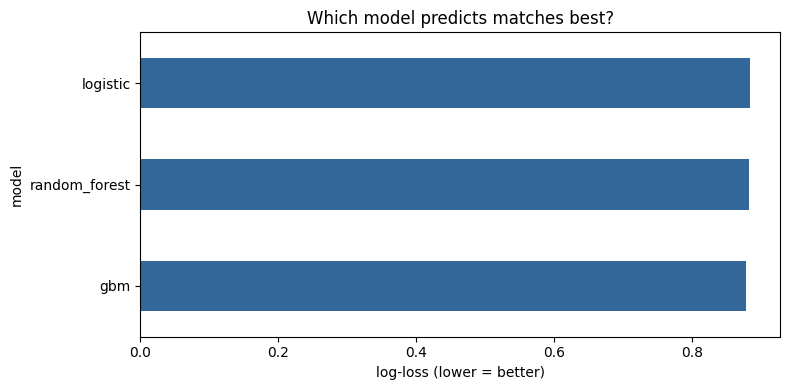

In [3]:
cmp = evaluate.compare_models(table, "2023-01-01")
display(Markdown("**Model comparison** (train 2019–2022, test 2023+). Lower log-loss / RPS is better."))
display(cmp.round(4))

ax = cmp["log_loss"].sort_values().plot.barh(color="#369")
ax.set_xlabel("log-loss (lower = better)"); ax.set_title("Which model predicts matches best?")
plt.tight_layout(); plt.show()

## 3. Is the result stable? Walk-forward validation

One split could be luck. We repeat the train/test split at several dates and average — the
proper way to judge a model on time-series, and the basis for any honest accuracy claim.

In [4]:
wf = evaluate.walk_forward(table, ["2022-01-01", "2023-01-01", "2024-01-01"])
display(Markdown("**Average across 3 split dates (2022/2023/2024):**"))
display(wf.sort_values("log_loss"))
best = wf["log_loss"].idxmin()
print(f"Most accurate (by log-loss): {best}")

**Average across 3 split dates (2022/2023/2024):**

,accuracy,log_loss,rps
model,,,
gbm,0.5887,0.8883,0.1746
random_forest,0.5930,0.8891,0.1749
logistic,0.5851,0.8943,0.1768


Most accurate (by log-loss): gbm


## 4. What drives the predictions? (feature importance)

Permutation importance on the gradient-boosting model: how much each feature matters to accuracy.

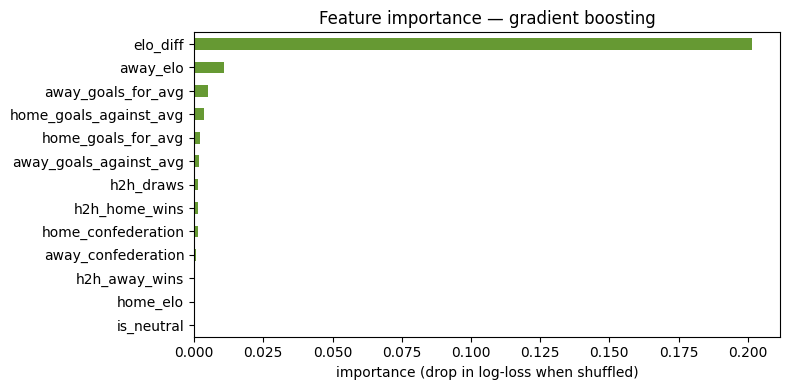

,importance
elo_diff,0.2016
away_elo,0.0108
away_goals_for_avg,0.0051
home_goals_against_avg,0.0037
home_goals_for_avg,0.0022
away_goals_against_avg,0.0018
h2h_draws,0.0015
h2h_home_wins,0.0015
home_confederation,0.0013
away_confederation,0.0007


In [5]:
clf = model.OutcomeClassifier("gbm").fit(table, "2023-01-01")
test = table[table["date"] >= "2023-01-01"].dropna(subset=model.FEATURES)
imp = clf.feature_importance(test, n_repeats=5)

ax = imp.iloc[::-1].plot.barh(color="#693")
ax.set_xlabel("importance (drop in log-loss when shuffled)")
ax.set_title("Feature importance — gradient boosting")
plt.tight_layout(); plt.show()
display(imp.round(4).to_frame("importance"))

## 5. Are the probabilities trustworthy? (calibration)

A model that says "70% home win" should be right ~70% of the time. We bin predictions and compare
predicted vs observed frequency — points on the diagonal mean well-calibrated probabilities.

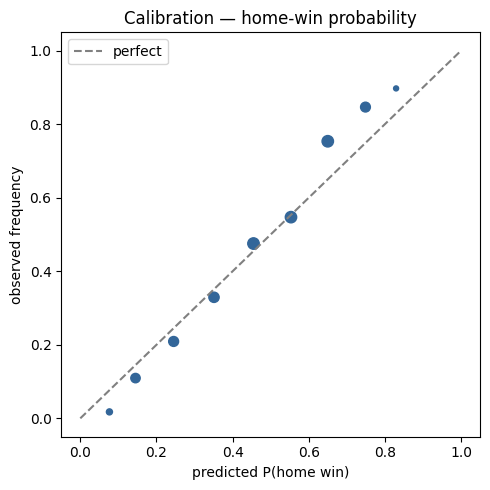

In [6]:
probs = clf.predict_proba_df(test)
cal = evaluate.calibration_table(probs, test["outcome"], outcome="H", bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], ls="--", c="gray", label="perfect")
ax.scatter(cal["pred_mean"], cal["obs_freq"], s=cal["n"] / 3, color="#369")
ax.set_xlabel("predicted P(home win)"); ax.set_ylabel("observed frequency")
ax.set_title("Calibration — home-win probability"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Predict a single match

Train on all data up to a cut-off, then predict any fixture (only the 32 teams with squad data).
The probabilities will sit close to the base rates — a direct reflection of the weak, tiny dataset.

In [7]:
fitted = model.OutcomeClassifier("random_forest").fit(table, "2026-06-11")
form = features.team_form()
h2h = features.h2h_table()

def predict(home, away, neutral=True):
    if home not in form.index or away not in form.index:
        return f"(no match history for {home if home not in form.index else away})"
    rec = h2h.get(tuple(sorted((home, away))), (1/3, 1/3, 1/3))
    if tuple(sorted((home, away)))[0] != home:
        rec = (rec[2], rec[1], rec[0])
    p = fitted.predict_match(model.match_features(form.loc[home], form.loc[away], neutral, rec))
    return {k: round(v, 3) for k, v in p.items()}

for h, a in [("Brazil", "Argentina"), ("France", "England"), ("Spain", "Germany")]:
    print(f"{h} vs {a}:  {predict(h, a)}")

Brazil vs Argentina:  {'A': 0.37, 'D': 0.393, 'H': 0.238}
France vs England:  {'A': 0.29, 'D': 0.426, 'H': 0.284}
Spain vs Germany:  {'A': 0.158, 'D': 0.279, 'H': 0.563}


## Takeaways

- The **Elo + form model reaches ~59% accuracy** (log-loss ~0.89) — the best yet, well above
  always-home (~44%), form-only (~56%) and Elo-only (~58%). **Random Forest is the best model.**
- **Elo and goal form are complementary:** Elo = opponent-adjusted long-term strength, form =
  recent scoring trend. h2h and confederation add little; neutral-venue is ~zero.
- Adding Elo also **improves draw prediction** — for evenly-matched sides (similar Elo) the model
  now correctly leans toward a draw.

**Note:** both Elo and form are results-derived (built from past matches) but leak-free — they only
use games played *before* the one predicted.